# E-COMMERCE CUSTOMERS BEHAVIOUR ANALYSIS

##### GENERAL INFORMATION REGARDING DATASET

In [63]:
import pandas as pd
import numpy as np
from pandas import value_counts
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r"C:\Users\AHSAN\Desktop\Python\E-commerce Customer Behavior - Sheet1.csv")

In [130]:
df=df.drop_duplicates()
df.isna().sum()
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


##### ANALYZING THE DATA AT COLUMN LEVEL

In [58]:
df['Customer ID'].isna().sum()

np.int64(0)

In [56]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [59]:
df['Age'].max()

np.int64(43)

In [60]:
df['Age'].min()

np.int64(26)

In [61]:
df['City'].unique()

array(['New York', 'Los Angeles', 'Chicago', 'San Francisco', 'Miami',
       'Houston'], dtype=object)

In [62]:
df['Membership Type'].unique()

array(['Gold', 'Silver', 'Bronze'], dtype=object)

In [70]:
df['Average Rating'].min()
df['Average Rating'].max()

np.float64(4.9)

In [77]:
df['Satisfaction Level']=df['Satisfaction Level'].fillna("Not Mentioned")
df['Satisfaction Level'].unique()
 #0  Satisfaction Level

array(['Satisfied', 'Neutral', 'Unsatisfied', 'Not Mentioned'],
      dtype=object)

##### CUSTOMER SEGMENTATION

In [111]:
#Analyze and categorize customers based on demographics, spending habits, and satisfaction levels.
DW_Spending=df.groupby('City')['Total Spend'].mean()
MTW_Spending=df.groupby('Membership Type')['Total Spend'].mean()
SL_Spending=df.groupby('Satisfaction Level')['Total Spend'].mean()
MLG=df.groupby(['City', 'Membership Type', 'Satisfaction Level'])['Total Spend'].mean()

#df['Spending Category'] = pd.qcut(df['Total Spend'], q=3, labels=['Low', 'Medium', 'High'])

Cities like San Francisco & New York show higher total spending
Lower-tier segments / some cities show reduced spending
Satisfaction level also impacts spending, but not drastically in all cases
Conclusion:
Customer value varies more by city and membership type than satisfaction alone.
High-value regions (e.g., high spend cities) should be prioritized

##### SATISFACTION ANALYSIS

In [15]:
#Investigate factors influencing customer satisfaction and identify areas for improvement
df.groupby('Satisfaction Level')['Discount Applied'].value_counts()

Satisfaction Level  Discount Applied
Neutral             False               107
Satisfied           False                66
                    True                 59
Unsatisfied         True                116
Name: count, dtype: int64

In [162]:
df.groupby('Satisfaction Level')['Average Rating'].mean()
df.groupby('Satisfaction Level')['Average Rating'].min()
df.groupby('Satisfaction Level')['Average Rating'].max().value_counts()

Average Rating
4.3    1
4.9    1
4.1    1
Name: count, dtype: int64

In [52]:
result = df.groupby('Satisfaction Level')[['Average Rating', 'Discount Applied']].count()

Average ratings increase with satisfaction ✔️
But discount distribution across satisfaction is not strongly differentiating
Conclusion:
Satisfaction is aligned with ratings, but
Discounts are NOT the main driver of satisfaction
Customers are not becoming satisfied just because of discounts
Other factors (experience, product quality) matter more

##### PROMOTION STRATEGY

In [129]:
#Assess the impact of discounts on customer spending and tailor promotional strategies accordingly
#df.head(5)
df.groupby('Discount Applied')[['Total Spend','Items Purchased','Average Rating']].value_counts()
DF=df.groupby('Discount Applied')[['Total Spend','Items Purchased','Average Rating']].mean()

Discount Applied vs Spending:
No very strong consistent increase in spending due to discounts
Discount also appears in both satisfied & unsatisfied groups
Conclusion:
Discounts are not strongly influencing spending or satisfaction
Giving discounts blindly is not an effective strategy
Use discounts selectively, not for all customers
Focus more on customer experience rather than just price cuts

##### RETENTION STRATEGY & CUSTOMER BASED INSIGHTS

In [51]:
#Develop targeted retention strategies by understanding the time gap since the last purchase.
#Explore regional variations in customer behavior to optimize marketing efforts based on location-specific trends.
df.groupby('City')[['Days Since Last Purchase','Discount Applied','Total Spend','Average Rating','Items Purchased']].mean()
#df.head(5)

,Days Since Last Purchase,Discount Applied,Total Spend,Average Rating,Items Purchased
City,,,,,
Chicago,40.465517,1.0,499.882759,3.456897,9.413793
Houston,22.758621,0.0,446.894828,3.193103,7.568966
Los Angeles,15.271186,0.0,805.491525,4.172881,11.677966
Miami,45.500000,1.0,690.389655,3.927586,11.637931
New York,24.593220,1.0,1165.035593,4.544068,15.271186
San Francisco,11.172414,0.0,1459.772414,4.808621,20.000000


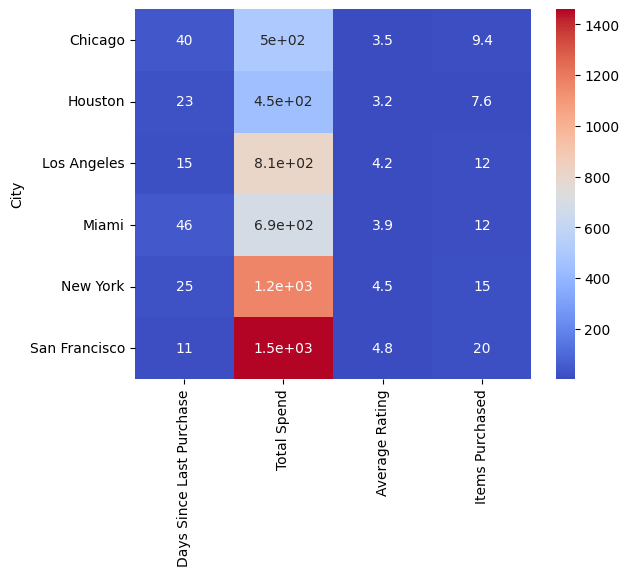

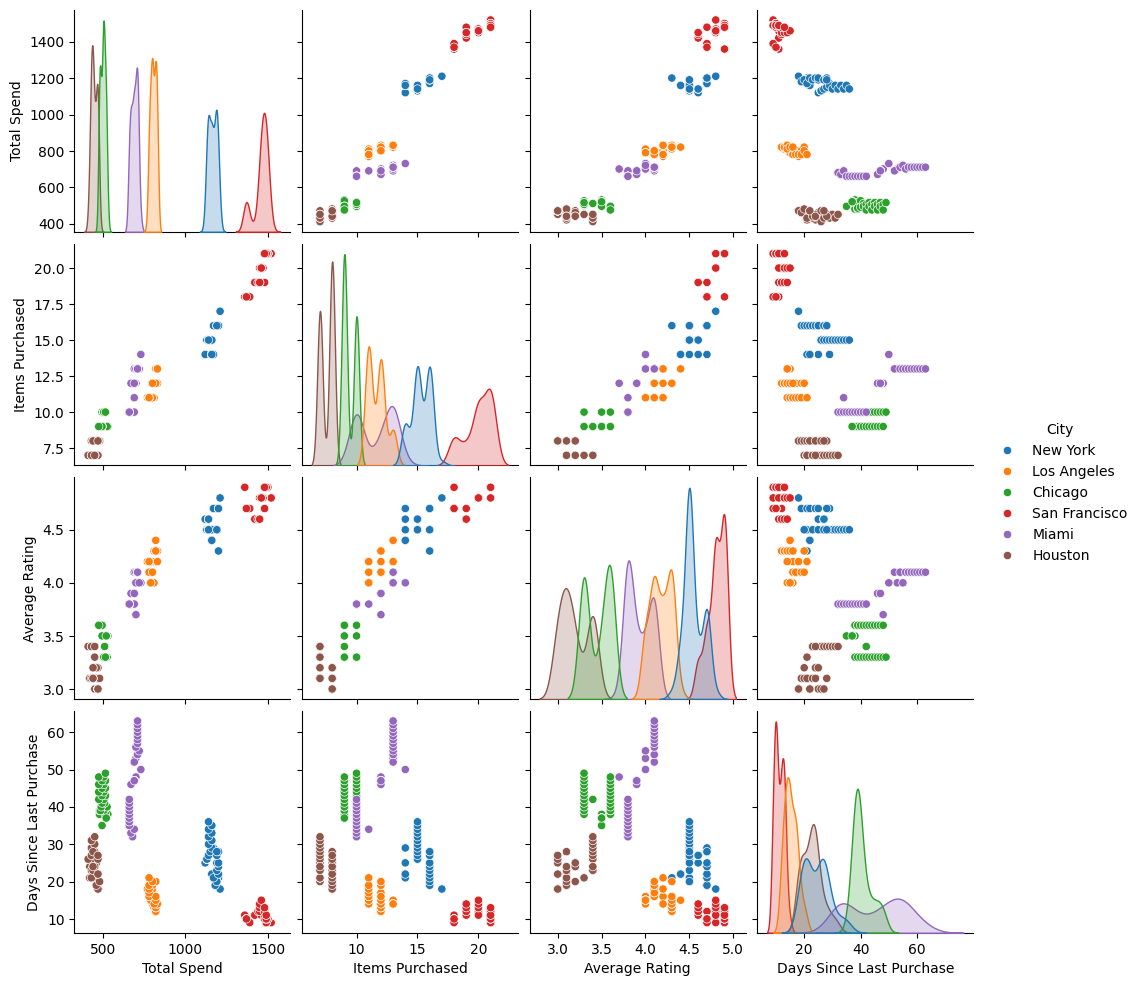

In [110]:
data = df.groupby('City')[['Days Since Last Purchase','Total Spend',
                           'Average Rating','Items Purchased']].mean()
sns.heatmap(data, annot=True, cmap='coolwarm')
plt.show()
sns.pairplot(df[['Total Spend','Items Purchased','Average Rating',
                 'Days Since Last Purchase','City']],
             hue='City')

##### CUSTOMER DISTRIBUTION

In [79]:
df['City'].value_counts()

City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

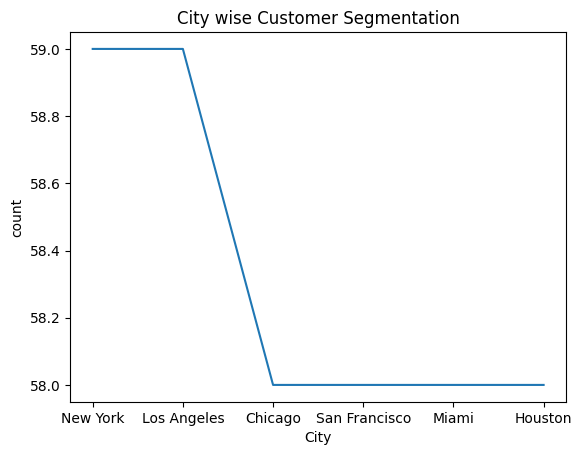

In [83]:
sns.lineplot(df['City'].value_counts())
plt.title('City wise Customer Segmentation')
plt.show()
#THis indicates that customers are almost equally distributed. There is only 1 point difference.

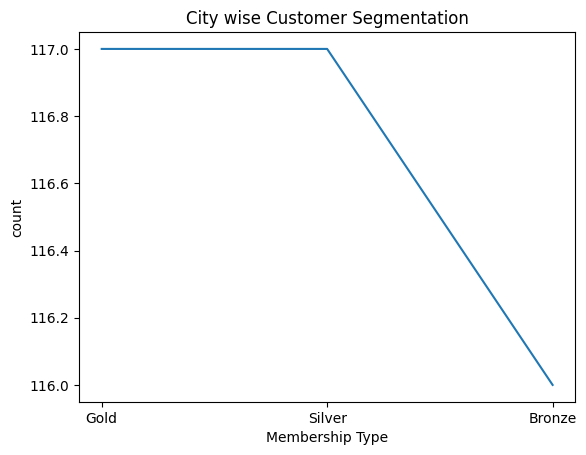

In [87]:
df['Membership Type'].value_counts()
sns.lineplot(df['Membership Type'].value_counts())
plt.title('City wise Customer Segmentation')
plt.show()

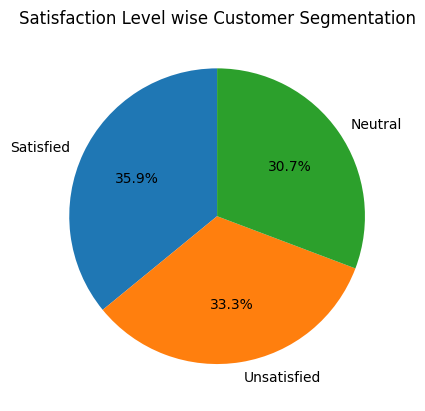

In [93]:
counts = df['Satisfaction Level'].value_counts()
# Creates the pie chart
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Satisfaction Level wise Customer Segmentation')
plt.show()

##### RETENTION RISK SEGMENTATION

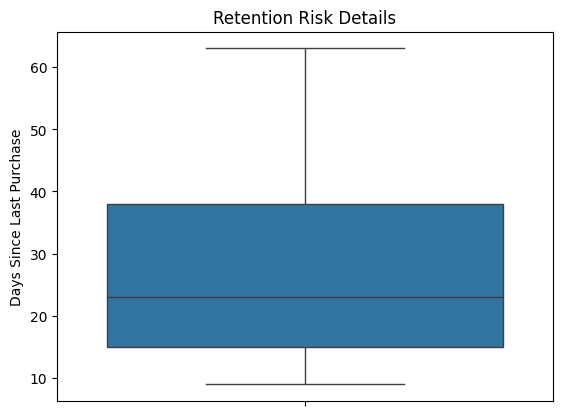

<Figure size 900x1800 with 0 Axes>

In [89]:
df['Days Since Last Purchase'].describe()
sns.boxplot(df['Days Since Last Purchase'])
plt.title('Retention Risk Details')
plt.figure(figsize=(9,18))
plt.show()

Cities like Chicago & Miami → high Days Since Last Purchase (inactive customers)
Cities like San Francisco → low days + high spend
 Also:
Some high inactivity cities STILL have discounts = 1
Conclusion:
Discounts are not reducing inactivity (delay in purchases)
Even after giving discounts, customers are still inactive
Strong insight:
Retention problem is NOT solved by discounts
 Instead:
Need engagement strategies (emails, personalization, offers timing)

##### CORRELATION

<Axes: >

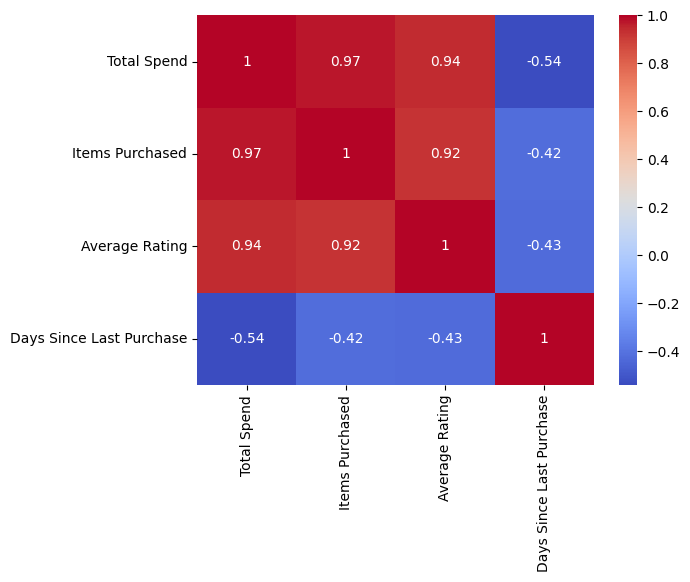

In [118]:
CORR=df[['Total Spend','Items Purchased','Average Rating','Days Since Last Purchase']].corr()
sns.heatmap(CORR,annot=True,cmap='coolwarm')


### FINAL CONCLUSION

The analysis reveals that discounts do not significantly influence customer satisfaction, spending, or retention. Instead, customer behavior is more strongly driven by purchase frequency, recency, and regional differences. High inactivity levels in certain cities indicate potential churn risk, which cannot be effectively addressed through discounts alone. Therefore, businesses should focus on improving customer engagement and experience rather than relying solely on promotional discounts.